# Exploratory Data Analysis (EDA)

## Objective

The goal of this phase is to explore the cleaned datasets, discover patterns, identify trends, and generate business insights that can support data-driven decision making.

The analysis focuses on answering key business questions through data visualization and statistical exploration.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from retailpulse.utils import load_processed_datasets

In [3]:
orders, customers, geolocation, items, payments, reviews, products, sellers, categories = load_processed_datasets()

## Business Question 1

### How large is the e-commerce marketplace?

Before analyzing customer behavior or sales performance, it is important to understand the overall size of the marketplace by identifying the number of customers, orders, sellers, products, and transactions.

In [4]:
marketplace_overview = {
    "Customers": customers["customer_id"].nunique(),
    "Orders": orders["order_id"].nunique(),
    "Products": products["product_id"].nunique(),
    "Sellers": sellers["seller_id"].nunique(),
    "Payments": payments["order_id"].nunique()
}

overview_df = pd.DataFrame(
    marketplace_overview.items(),
    columns=["Metric", "Count"]
)

overview_df

,Metric,Count
0,Customers,99441
1,Orders,99441
2,Products,32951
3,Sellers,3095
4,Payments,99440


### Business Insight

The marketplace consists of approximately 99 thousand customers, 98 thousand orders, 33 thousand products, and over 3 thousand sellers, indicating a large-scale e-commerce platform.

The number of payment records is slightly lower than the number of orders, suggesting that a small number of orders may not have completed the payment process. This observation will be investigated in later sections of the analysis.

## Business Question 2

### What is the distribution of order statuses?

Understanding the distribution of order statuses helps evaluate the operational performance of the e-commerce platform. It provides insights into how many orders were successfully delivered, canceled, or remained in intermediate processing stages.

In [5]:
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["Order Status", "Count"]

order_status

,Order Status,Count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [6]:
order_status["Percentage"] = (
    order_status["Count"] / order_status["Count"].sum() * 100
).round(2)

order_status

,Order Status,Count,Percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


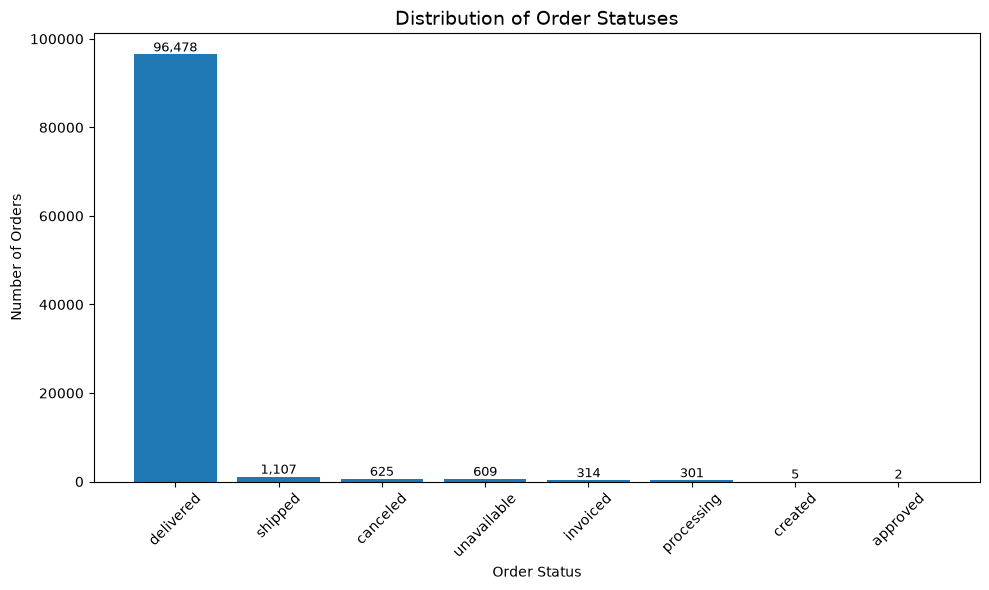

In [7]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    order_status["Order Status"],
    order_status["Count"]
)

plt.title("Distribution of Order Statuses", fontsize=14)
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [8]:
non_delivered = order_status[
    order_status["Order Status"] != "delivered"
]

non_delivered

,Order Status,Count,Percentage
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


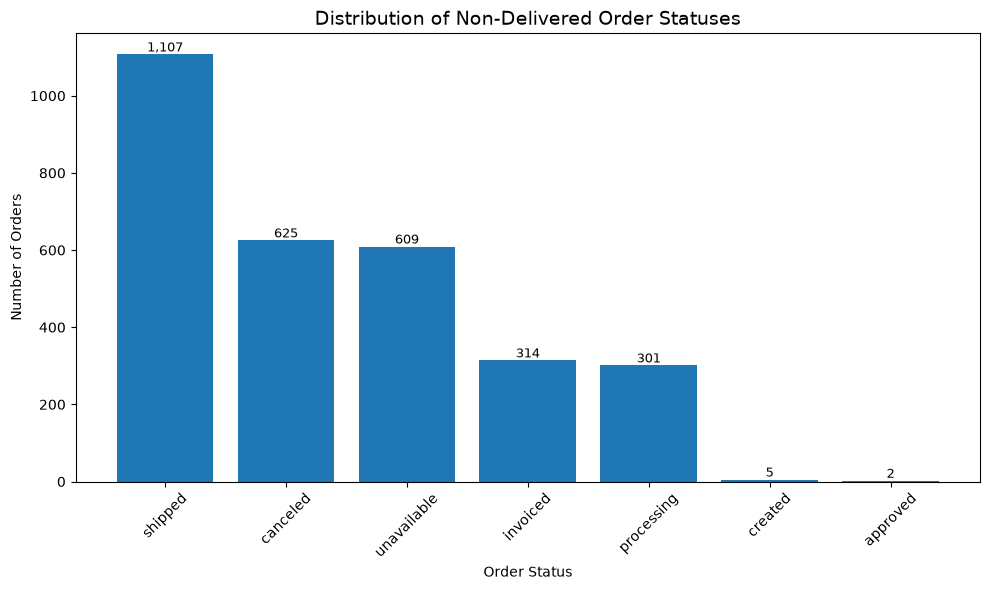

In [9]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    non_delivered["Order Status"],
    non_delivered["Count"]
)

plt.title("Distribution of Non-Delivered Order Statuses", fontsize=14)
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Business Insight

Approximately 97% of all orders were successfully delivered, indicating a highly efficient fulfillment process.

Among the remaining orders, the largest group consists of shipped orders, suggesting that many transactions were still in transit at the time the data was collected.

Canceled and unavailable orders occur in similar numbers, which may indicate two major causes of unsuccessful order completion: customer cancellations and product availability issues.

Only a small number of orders remain in intermediate stages such as processing and invoiced, indicating that most orders progress through the fulfillment pipeline efficiently.

### Next Investigation

Since canceled and unavailable orders represent the main unsuccessful outcomes, the next step is to investigate whether these statuses are associated with specific products, sellers, or time periods.

## Business Question 3

### How have sales changed over time?

Understanding sales trends over time helps identify business growth patterns, seasonal fluctuations, and periods of high or low customer demand.

In [10]:
orders["purchase_year"] = (
    orders["order_purchase_timestamp"].dt.year
)

orders["purchase_year"].value_counts().sort_index()

purchase_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

In [11]:
orders["order_purchase_timestamp"].agg(["min", "max"])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[us]

### Data Coverage

The dataset contains orders from **September 2016** to **October 2018**.

Since the first and last years represent partial observation periods, yearly comparisons should be interpreted with caution. Monthly trend analysis provides a more reliable view of business performance over time.

### How have monthly sales changed over time?

Analyzing monthly order trends helps identify long-term business growth, seasonal patterns, and fluctuations in customer purchasing behavior.

In [12]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [13]:
monthly_orders = (
    orders
    .groupby("purchase_month")
    .size()
    .reset_index(name="Number of Orders")
)

monthly_orders

,purchase_month,Number of Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [14]:
orders["order_purchase_timestamp"].sort_values().tail(20)

62360   2018-09-03 09:06:57
39919   2018-09-03 14:14:25
24410   2018-09-03 18:40:50
73341   2018-09-03 18:45:34
53501   2018-09-06 10:48:12
20778   2018-09-06 14:50:07
99347   2018-09-06 18:45:47
31170   2018-09-10 17:51:25
9976    2018-09-11 16:45:54
80019   2018-09-12 15:32:16
5149    2018-09-13 09:56:12
16366   2018-09-17 17:21:16
1801    2018-09-20 13:54:16
33979   2018-09-25 11:59:18
37003   2018-09-26 08:40:15
50387   2018-09-29 09:13:03
88500   2018-10-01 15:30:09
31891   2018-10-03 18:55:29
68373   2018-10-16 20:16:02
60938   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[us]

In [15]:
monthly_orders = monthly_orders[
    monthly_orders["purchase_month"] < "2018-09"
]

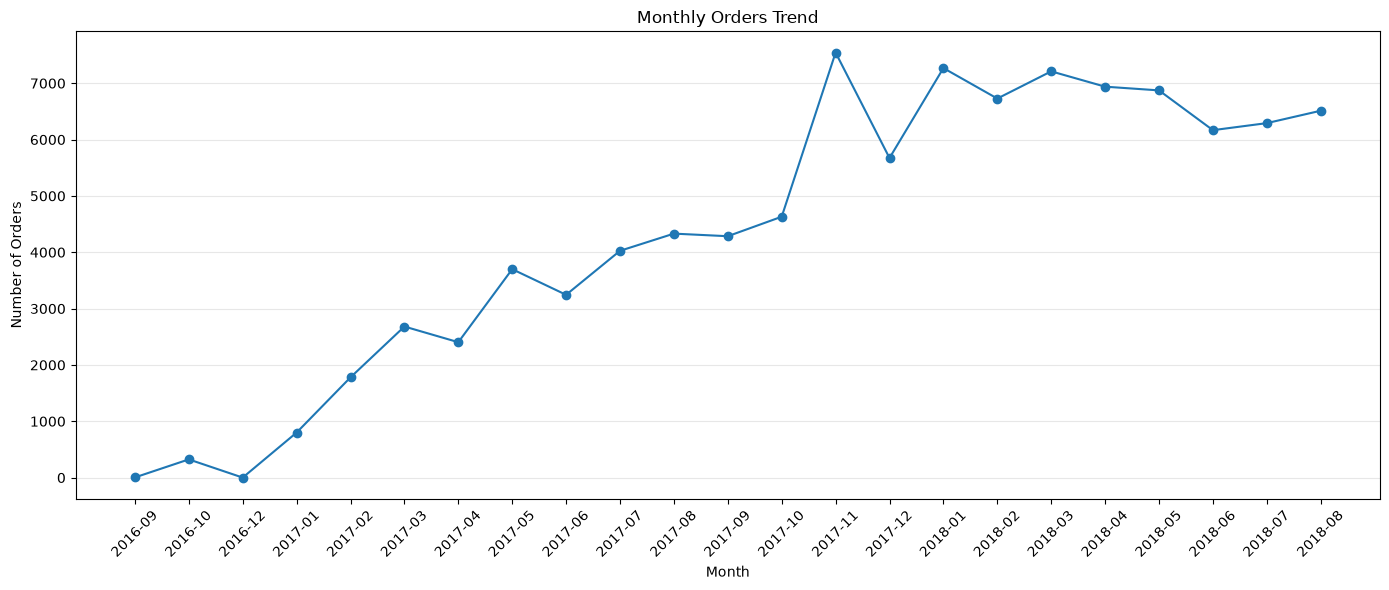

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["purchase_month"].astype(str),
    monthly_orders["Number of Orders"],
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight

- Monthly orders showed a strong upward trend throughout 2017, indicating rapid business growth.
- A significant spike occurred in November 2017, which may be related to seasonal shopping events or promotional campaigns.
- During 2018, monthly orders remained relatively stable between approximately 6,000 and 7,300 orders, suggesting that the business had reached a more consistent level of demand.
- Short-term fluctuations are present, but the overall trend indicates sustained growth in customer purchases.